In [1]:
import sys
import os
from itertools import groupby
from operator import itemgetter
from pathlib import Path  # noqa: F401

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import spearmanr

# Resolve project root regardless of where the notebook is launched from
for _candidate in [".", "..", "../.."]:
    _p = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_p, "src")):
        sys.path.insert(0, _p)
        break

from src.analysis.isc import (  # noqa: E402
    compute_loo_isc,
    compute_loo_isc_spearman,
    compute_pairwise_isc,
    compute_pairwise_isc_spearman,
    compute_sliding_window_isc,
    compute_sliding_window_isc_spearman,
)
from src.definitions.constants import ProjectPaths  # noqa: E402
from src.definitions.fields import (  # noqa: E402
    ConditionVariants,
    ExclusionCategories,
    MusicTypeVariants,
)
from src.visualization.isc_plots import print_data_overview  # noqa: E402
from scripts.analysis_common import analyzers_to_datasets, load_analyzers  # noqa: E402

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)


# EEG Inter-Subject Correlation Analysis — Broadband (Raw, Unnormalized)

This notebook computes **inter-subject correlation (ISC)** on the raw EEG
signal (unnormalized amplitudes) across frequency bands:

1. **LOO-ISC distribution** — for each subject, Pearson and Spearman correlation
   against the mean of all others; histogram and per-subject violin plot
2. **Pairwise ISC matrix** — symmetric subject × subject correlation matrix;
   per-subject mean off-diagonal for outlier detection
3. **Sliding-window (time-resolved) ISC** — LOO-ISC as a time course with
   per-channel heatmap; Pearson vs Spearman comparison at medium window

Spearman functions (`compute_loo_isc_spearman`, `compute_pairwise_isc_spearman`,
`compute_sliding_window_isc_spearman`) are imported from `src.analysis.isc`.


## Configuration


In [2]:
# ── Experiment configuration ───────────────────────────────────────────────
CONDITION = ConditionVariants.PLACEBO
MUSIC_TYPES = [MusicTypeVariants.CLASSICAL, MusicTypeVariants.PSYTRANCE]
EXCLUSION_CATEGORIES = [ExclusionCategories.BAD_MUSIC, ExclusionCategories.ARTIFACTS]

# ── Data processing flag ───────────────────────────────────────────────────
# Set True to load raw EDF files, resample, stack, and save before analysis.
# Keep False to use already-saved concatenated arrays.
process_and_save_data = False

# ── LOO-ISC distribution parameters ───────────────────────────────────────
PLOT_PCT = 99  # clip histogram at this percentile to suppress outliers

# ── Sliding-window ISC parameters ─────────────────────────────────────────
# Three non-overlapping window sizes; step = window in each case.
# Fine   — appears nearly continuous; also used for the per-channel heatmap.
# Medium — main analysis window for the bar chart and Pearson/Spearman comparison.
# Large  — coarse long-range trend.
WINDOW_FINE_SEC = 1.0     # fine / one-step window (seconds)
WINDOW_MED_SEC = 5.0      # medium window (seconds)
WINDOW_LARGE_SEC = 15.0   # large window (seconds)
ISC_THRESHOLD = 0.035     # significance highlight threshold (r)

# Sub-sample channels for Spearman to keep runtime manageable during exploration.
# Set to None to use all channels (much slower).
N_CH_SUBSAMPLE = 64

# ── Plot saving ────────────────────────────────────────────────────────────
SAVE_PLOTS = True

PLOTS_DIR = ProjectPaths.NOTEBOOKS_DIR / "02-isc-broadband-analysis" / "plots" / "broadband"
print(f"Plots will be saved to: {PLOTS_DIR}")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


Plots will be saved to: /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/notebooks/02-isc-broadband-analysis/plots/broadband


## Data Loading


In [3]:
# Load (or process-and-save) one EEGSummarizedAnalyzer per music type.
# normalize_data=False: keep raw amplitudes for this ISC analysis.
analyzers = load_analyzers(
    MUSIC_TYPES,
    CONDITION,
    EXCLUSION_CATEGORIES,
    process_and_save_data,
    normalize_data=False,
)
datasets = analyzers_to_datasets(analyzers)
print_data_overview(datasets)


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif...
    Range : 19254 ... 384821 =     19.254 ...   384.821 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI035_EEGB_MUSIC_CLASSIC_EC_20180209_124821.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


Opening raw data file /auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI040_EEGB_MUSIC_PSYTRANCE_EC_20181011_124255.fif...
    Range : 23383 ... 508124 =     23.383 ...   508.124 secs
Ready.


/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/src/io/loading.py:110: RuntimeWarning: This filename (/auto/vestec1-elixir/home/dbeinhauer/psilocybin-eeg/data/processed/psilo_music/cropped/PSI040_EEGB_MUSIC_PSYTRANCE_EC_20181011_124255.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(


## Dataset Selection

Change `LABEL` to switch between music types. All analysis cells below use
`ad`, `data`, `n_subjects`, `n_channels`, `n_times`, and `sfreq`.


In [4]:
LABEL = MusicTypeVariants.CLASSICAL.value
# LABEL = MusicTypeVariants.PSYTRANCE.value

ad = datasets[LABEL]
data = ad.data        # (n_subjects, n_channels, n_times) — unnormalized
sfreq = ad.sfreq

n_subjects, n_channels, n_times = data.shape
time = np.arange(n_times) / sfreq   # seconds

print(f"Dataset : {LABEL}")
print(f"Shape   : {data.shape}  (subjects × channels × time points)")
print(f"Duration: {n_times / sfreq:.1f} s  @  {sfreq} Hz")
print("Data: unnormalized (raw amplitude).")


Dataset : CLASSIC
Shape   : (15, 195, 91392)  (subjects × channels × time points)
Duration: 365.6 s  @  250.0 Hz
Data: unnormalized (raw amplitude).


## Section 1 — LOO-ISC Distribution (Pearson vs. Spearman)

For each subject *s*, the channel-wise correlation between subject *s* and the
**mean of all other subjects** is computed (**leave-one-out ISC**).

- **Histogram** — distribution of channel-wise mean LOO-ISC; how many channels
  show above-chance inter-subject agreement (clipped at `PLOT_PCT` to suppress outliers)
- **Per-subject violin + strip** — each dot is one subject's mean LOO-ISC
  averaged over channels; reveals outlier subjects
- **Pearson** captures linear synchrony; **Spearman** is robust to the amplitude
  outliers present


Computing Pearson LOO-ISC …
Computing Spearman LOO-ISC …


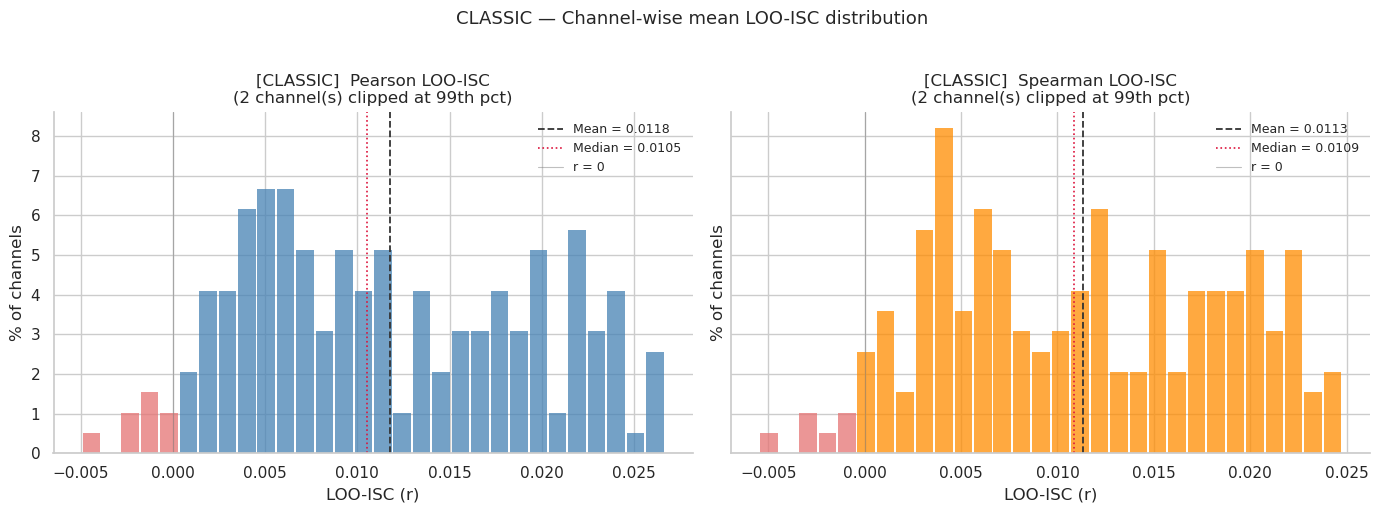

/tmp/ipykernel_207606/1759277920.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


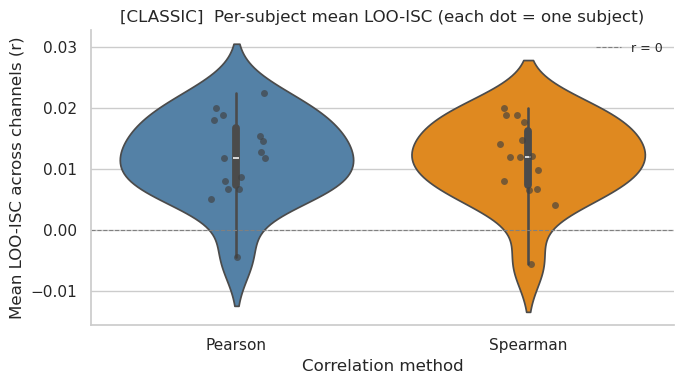


Pearson  LOO-ISC — mean: 0.0118  std: 0.0078  % channels > 0: 96.4%
Spearman LOO-ISC — mean: 0.0113  std: 0.0074  % channels > 0: 96.9%


In [5]:
print("Computing Pearson LOO-ISC …")
loo_pearson, mean_isc_pearson = compute_loo_isc(data)
# loo_pearson:      (n_subjects, n_channels)
# mean_isc_pearson: (n_channels,) — channel-wise group ISC

print("Computing Spearman LOO-ISC …")
loo_spearman, mean_isc_spearman = compute_loo_isc_spearman(data)

# ── Histogram: Pearson vs. Spearman side by side ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, mean_isc, color, method in zip(
    axes,
    [mean_isc_pearson, mean_isc_spearman],
    ["steelblue", "darkorange"],
    ["Pearson", "Spearman"],
):
    clip = np.percentile(mean_isc, PLOT_PCT)
    n_out = int((mean_isc > clip).sum())
    vals = mean_isc[mean_isc <= clip]
    counts, edges = np.histogram(vals, bins=30)
    pct_vals = counts / n_channels * 100
    centers = 0.5 * (edges[:-1] + edges[1:])

    _hist_colors = [color if c >= 0 else "#e57373" for c in centers]
    ax.bar(centers, pct_vals, width=(edges[1] - edges[0]) * 0.9,
           color=_hist_colors, alpha=0.75, edgecolor="none")
    ax.axvline(np.mean(mean_isc), color=".2", ls="--", lw=1.3,
               label=f"Mean = {np.mean(mean_isc):.4f}")
    ax.axvline(np.median(mean_isc), color="crimson", ls=":", lw=1.2,
               label=f"Median = {np.median(mean_isc):.4f}")
    ax.axvline(0, color="gray", ls="-", lw=0.8, alpha=0.5, label="r = 0")
    ax.set_xlabel("LOO-ISC (r)")
    ax.set_ylabel("% of channels")
    ax.set_title(
        f"[{LABEL}]  {method} LOO-ISC\n"
        f"({n_out} channel(s) clipped at {PLOT_PCT}th pct)"
    )
    ax.legend(frameon=False, fontsize=9)

sns.despine(fig=fig)
fig.suptitle(f"{LABEL} — Channel-wise mean LOO-ISC distribution", fontsize=13, y=1.02)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / f"loo_isc_distribution_{LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-subject violin + strip plot ──────────────────────────────────────
df_subj = pd.concat([
    pd.DataFrame({
        "subject": np.arange(n_subjects),
        "mean_isc": loo_pearson.mean(axis=1),
        "method": "Pearson",
    }),
    pd.DataFrame({
        "subject": np.arange(n_subjects),
        "mean_isc": loo_spearman.mean(axis=1),
        "method": "Spearman",
    }),
])

fig2, ax2 = plt.subplots(figsize=(7, 4))
sns.violinplot(
    data=df_subj, x="method", y="mean_isc",
    palette={"Pearson": "steelblue", "Spearman": "darkorange"},
    inner="box", ax=ax2,
)
sns.stripplot(
    data=df_subj, x="method", y="mean_isc",
    color=".25", size=5, jitter=True, alpha=0.65, ax=ax2,
)
ax2.axhline(0, color="gray", ls="--", lw=0.8, label="r = 0")
ax2.set_xlabel("Correlation method")
ax2.set_ylabel("Mean LOO-ISC across channels (r)")
ax2.set_title(f"[{LABEL}]  Per-subject mean LOO-ISC (each dot = one subject)")
ax2.legend(frameon=False, fontsize=9)
sns.despine(fig=fig2)
fig2.tight_layout()
if SAVE_PLOTS:
    fig2.savefig(PLOTS_DIR / f"loo_isc_per_subject_{LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    f"\nPearson  LOO-ISC — mean: {mean_isc_pearson.mean():.4f}  "
    f"std: {mean_isc_pearson.std():.4f}  "
    f"% channels > 0: {(mean_isc_pearson > 0).mean() * 100:.1f}%"
)
print(
    f"Spearman LOO-ISC — mean: {mean_isc_spearman.mean():.4f}  "
    f"std: {mean_isc_spearman.std():.4f}  "
    f"% channels > 0: {(mean_isc_spearman > 0).mean() * 100:.1f}%"
)


## Section 2 — Pairwise ISC Matrix (Pearson vs. Spearman)

Every pair of subjects is correlated (mean over channels) producing a symmetric
`(n_subjects × n_subjects)` matrix:

- **Heatmaps** — diagonal masked so the colour scale focuses on off-diagonal spread
- **Per-subject mean off-diagonal bar chart** — subjects with consistently low
  values are candidates for quality review
- **Off-diagonal distribution** — histogram comparing the spread of pairwise
  correlations for both methods


Computing Pearson pairwise ISC …
Computing Spearman pairwise ISC …


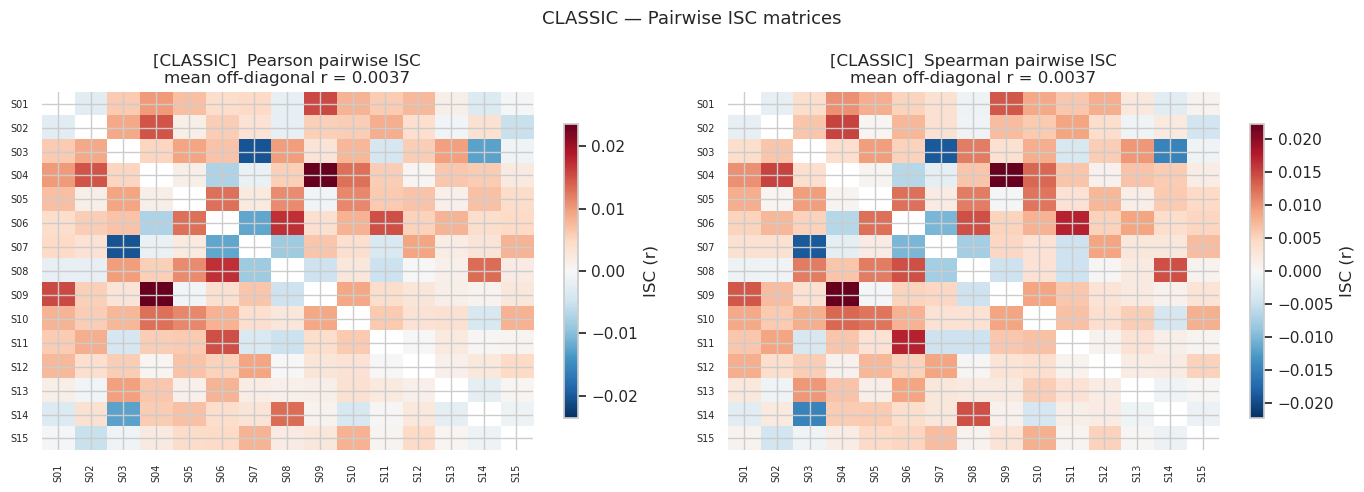

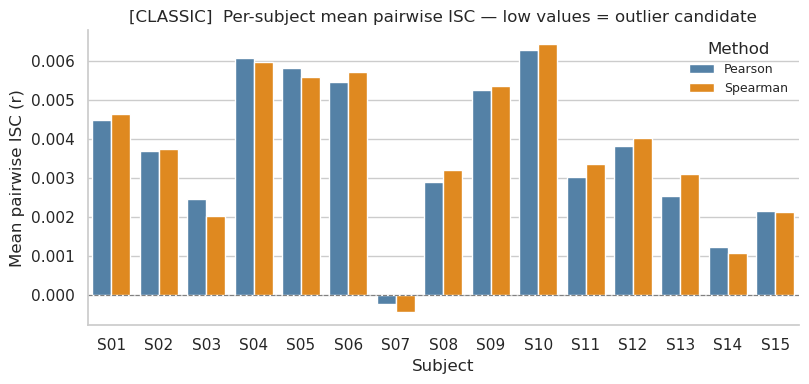

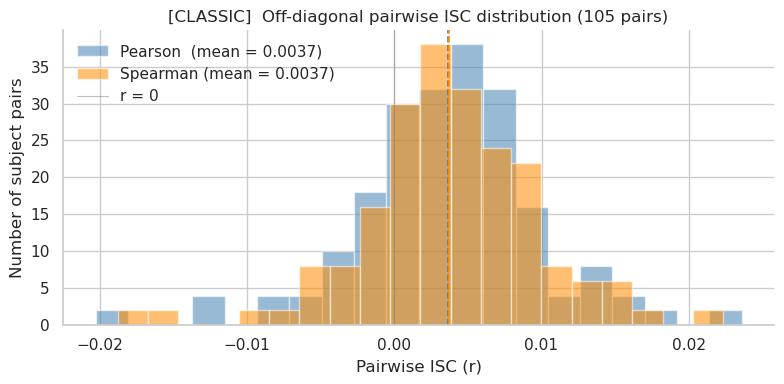

In [6]:
print("Computing Pearson pairwise ISC …")
pair_pearson = compute_pairwise_isc(data)
# pair_pearson: (n_subjects, n_subjects)

print("Computing Spearman pairwise ISC …")
pair_spearman = compute_pairwise_isc_spearman(data)

subj_labels = [f"S{i + 1:02d}" for i in range(n_subjects)]
off_diag_mask = ~np.eye(n_subjects, dtype=bool)

# ── Side-by-side heatmaps ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, method in zip(
    axes,
    [pair_pearson, pair_spearman],
    ["Pearson", "Spearman"],
):
    mat_display = mat.copy()
    np.fill_diagonal(mat_display, np.nan)
    vmax = max(np.nanmax(np.abs(mat_display)), 0.01)

    im = ax.imshow(mat_display, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
    plt.colorbar(im, ax=ax, label="ISC (r)", shrink=0.82)
    ax.set_xticks(range(n_subjects))
    ax.set_yticks(range(n_subjects))
    ax.set_xticklabels(subj_labels, rotation=90, fontsize=7)
    ax.set_yticklabels(subj_labels, fontsize=7)
    mean_off = float(mat[off_diag_mask].mean())
    ax.set_title(f"[{LABEL}]  {method} pairwise ISC\nmean off-diagonal r = {mean_off:.4f}")

sns.despine(fig=fig, left=True, bottom=True)
fig.suptitle(f"{LABEL} — Pairwise ISC matrices", fontsize=13)
fig.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOTS_DIR / f"pairwise_isc_matrix_{LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Per-subject mean off-diagonal ISC ──────────────────────────────────────
mean_off_pearson_subj = np.array(
    [pair_pearson[i, off_diag_mask[i]].mean() for i in range(n_subjects)]
)
mean_off_spearman_subj = np.array(
    [pair_spearman[i, off_diag_mask[i]].mean() for i in range(n_subjects)]
)
df_off = pd.DataFrame({
    "subject": subj_labels * 2,
    "mean_pairwise_isc": np.concatenate([mean_off_pearson_subj, mean_off_spearman_subj]),
    "method": ["Pearson"] * n_subjects + ["Spearman"] * n_subjects,
})

fig2, ax2 = plt.subplots(figsize=(max(8, n_subjects * 0.55), 4))
sns.barplot(
    data=df_off, x="subject", y="mean_pairwise_isc", hue="method",
    palette={"Pearson": "steelblue", "Spearman": "darkorange"},
    ax=ax2,
)
ax2.axhline(0, color="gray", ls="--", lw=0.8)
ax2.set_xlabel("Subject")
ax2.set_ylabel("Mean pairwise ISC (r)")
ax2.set_title(f"[{LABEL}]  Per-subject mean pairwise ISC — low values = outlier candidate")
ax2.legend(frameon=False, fontsize=9, title="Method")
sns.despine(fig=fig2)
fig2.tight_layout()
if SAVE_PLOTS:
    fig2.savefig(PLOTS_DIR / f"pairwise_isc_per_subject_{LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Off-diagonal distribution ─────────────────────────────────────────────
off_p = pair_pearson[off_diag_mask]
off_s = pair_spearman[off_diag_mask]
n_pairs = n_subjects * (n_subjects - 1) // 2

fig3, ax3 = plt.subplots(figsize=(8, 4))
ax3.hist(off_p, bins=20, alpha=0.55, color="steelblue",
         label=f"Pearson  (mean = {off_p.mean():.4f})")
ax3.hist(off_s, bins=20, alpha=0.55, color="darkorange",
         label=f"Spearman (mean = {off_s.mean():.4f})")
ax3.axvline(off_p.mean(), color="steelblue", ls="--", lw=1.2)
ax3.axvline(off_s.mean(), color="darkorange", ls="--", lw=1.2)
ax3.axvline(0, color="gray", ls="-", lw=0.8, alpha=0.5, label="r = 0")
ax3.set_xlabel("Pairwise ISC (r)")
ax3.set_ylabel("Number of subject pairs")
ax3.set_title(f"[{LABEL}]  Off-diagonal pairwise ISC distribution ({n_pairs} pairs)")
ax3.legend(frameon=False)
sns.despine(fig=fig3)
fig3.tight_layout()
if SAVE_PLOTS:
    fig3.savefig(PLOTS_DIR / f"pairwise_isc_distribution_{LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()


## Section 3 — Time-Resolved LOO-ISC (Multi-Scale Windowed Analysis)

Non-overlapping LOO-ISC is computed at **three temporal scales** (fine / medium / large).

**Figure A — Bar chart (medium window, Pearson)**
Each bar is one non-overlapping window coloured green when its mean ISC exceeds `ISC_THRESHOLD`; error bars show ±std across channels. Highlights which segments of the recording have significant inter-subject synchrony.

**Figure B — Stair-step overlay + per-channel heatmap (Pearson)**
Upper panel overlays the three stair-step mean-ISC curves (fine / medium / large). Gold shading marks significant medium-window spans. Lower panel is a fine-window per-channel ISC heatmap.

**Figure C — Pearson vs. Spearman comparison (medium window)**
Overlay of Pearson and Spearman time courses showing how robust the synchrony signal is to rank-based estimation.


Using 64/195 randomly subsampled channels.
  Pearson ISC  (1 s non-overlapping) …
  Pearson ISC  (5 s non-overlapping) …
  Pearson ISC  (15 s non-overlapping) …
  Spearman ISC (5 s non-overlapping) …


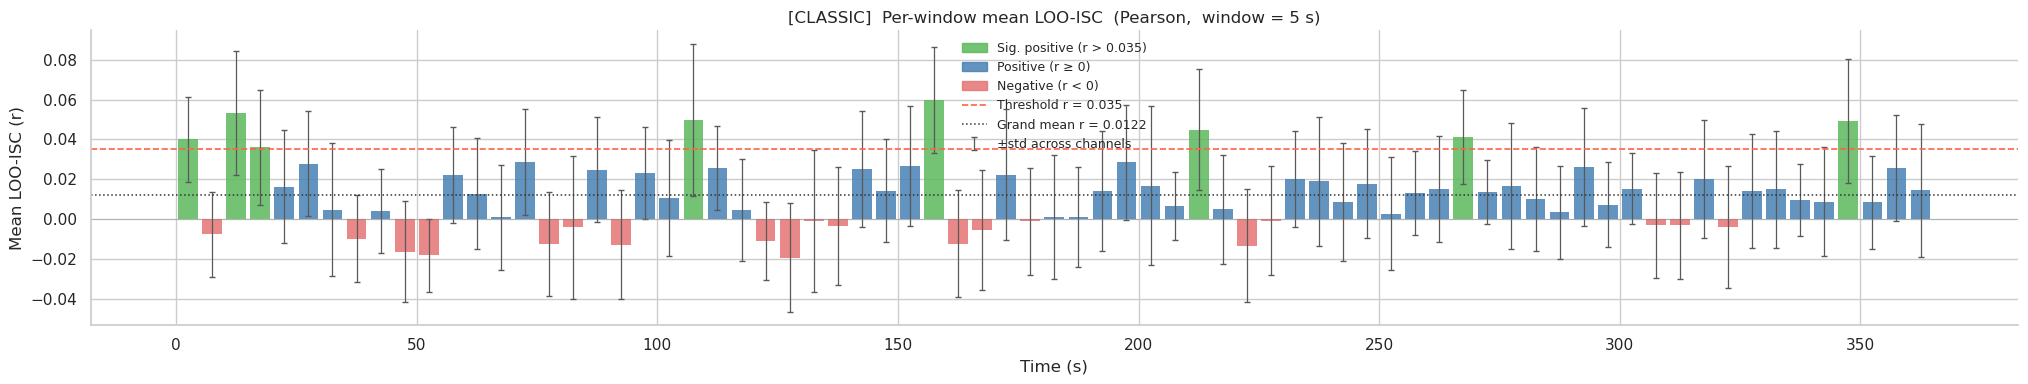


Significant windows (5 s): 8/73 (11.0%)  |  threshold r = 0.035
  #  Start (s)  End (s)   Mean r   Peak r
  1        0.0      5.0   0.0400   0.0400
  2       10.0     20.0   0.0446   0.0533
  3      105.0    110.0   0.0498   0.0498
  4      155.0    160.0   0.0598   0.0598
  5      210.0    215.0   0.0449   0.0449
  6      265.0    270.0   0.0413   0.0413
  7      345.0    350.0   0.0493   0.0493


/tmp/ipykernel_207606/4257253896.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_ov.tight_layout()


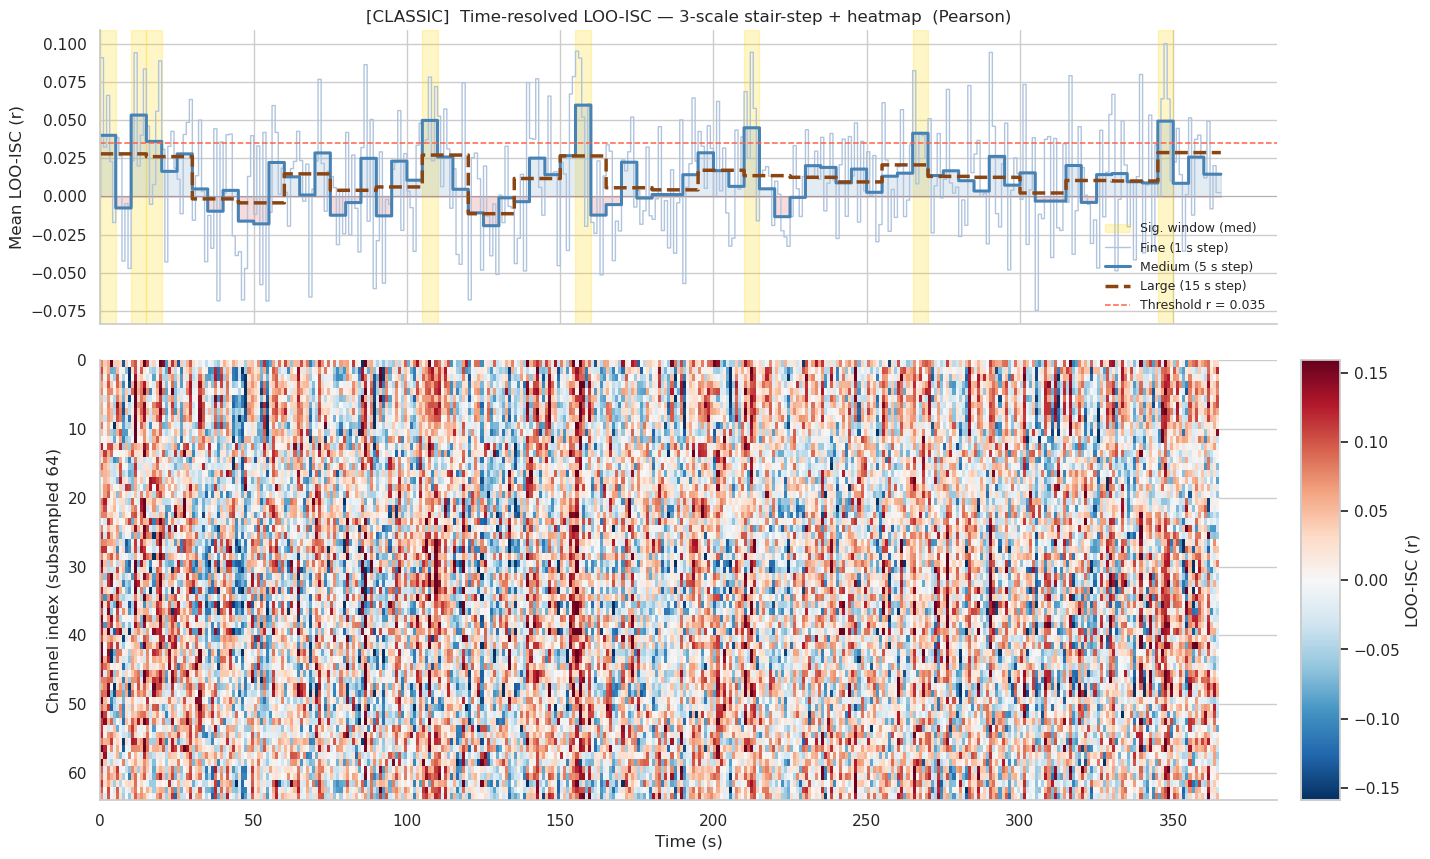

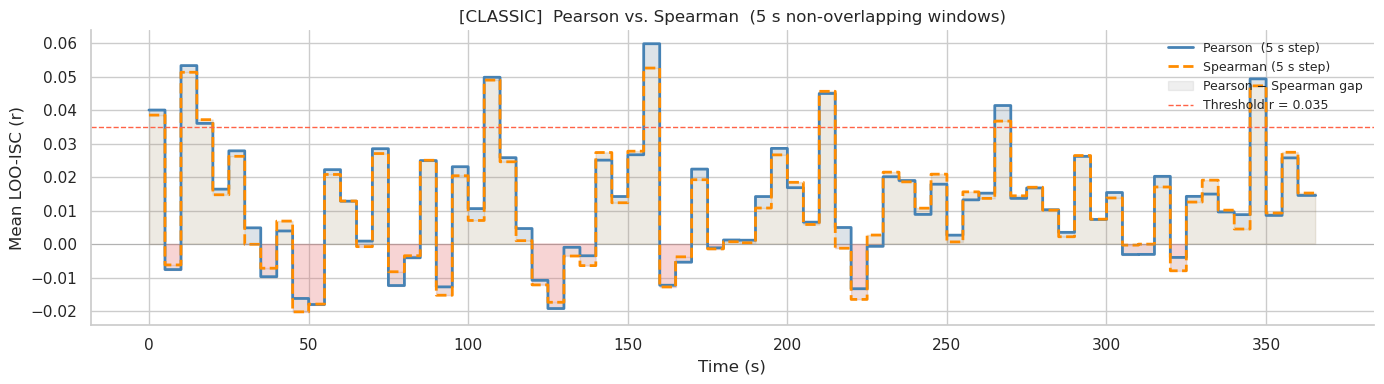


Correlation between Pearson and Spearman LOO-ISC time courses: r = 0.9904


In [7]:
# ── Helper: build a native-resolution step array ─────────────────────────
def _make_step_arr(mean_tc: np.ndarray, win_samples: int, n_times_full: int) -> np.ndarray:
    """Repeat each window value for win_samples ticks, then pad/trim to n_times_full."""
    repeated = np.repeat(mean_tc, win_samples)
    pad = n_times_full - len(repeated)
    if pad > 0:
        return np.pad(repeated, (0, pad), mode="edge")
    return repeated[:n_times_full]


C_GREEN = "#5cb85c"
C_NEG = "#e57373"
C_THRESH = "tomato"
C_SYNC = "gold"

# ── Channel subsampling (same subset for all methods / window sizes) ────────
if N_CH_SUBSAMPLE is not None and N_CH_SUBSAMPLE < n_channels:
    rng = np.random.default_rng(42)
    ch_idx = np.sort(rng.choice(n_channels, N_CH_SUBSAMPLE, replace=False))
    data_sw = data[:, ch_idx, :]
    print(f"Using {N_CH_SUBSAMPLE}/{n_channels} randomly subsampled channels.")
else:
    data_sw = data
    ch_idx = np.arange(n_channels)

n_ch_sw = data_sw.shape[1]
n_times_sw = data_sw.shape[2]
time_s = np.arange(n_times_sw) / sfreq   # native time axis (seconds)
ch_label_sw = "Channel index"
if N_CH_SUBSAMPLE is not None and N_CH_SUBSAMPLE < n_channels:
    ch_label_sw += f" (subsampled {n_ch_sw})"

# ── Compute non-overlapping ISC at 3 window sizes (Pearson) ────────────────
win_configs = [
    ("fine",  WINDOW_FINE_SEC,  "lightsteelblue", "solid",  1.0),
    ("med",   WINDOW_MED_SEC,   "steelblue",      "solid",  2.2),
    ("large", WINDOW_LARGE_SEC, "saddlebrown",    "dashed", 2.5),
]

sw_data = {}
for name, win_sec, color, ls, lw in win_configs:
    print(f"  Pearson ISC  ({win_sec:.0f} s non-overlapping) …")
    isc_tc, sw_times = compute_sliding_window_isc(
        data_sw, win_sec, win_sec, sfreq
    )
    win_samples = int(round(win_sec * sfreq))
    mean_tc = isc_tc.mean(axis=1)
    step_arr = _make_step_arr(mean_tc, win_samples, n_times_sw)
    sw_data[name] = dict(
        win_sec=win_sec,
        isc_tc=isc_tc,
        sw_times=sw_times,
        mean_tc=mean_tc,
        step_arr=step_arr,
        win_samples=win_samples,
        color=color,
        ls=ls,
        lw=lw,
    )

# Medium Spearman for method comparison
print(f"  Spearman ISC ({WINDOW_MED_SEC:.0f} s non-overlapping) …")
sw_spear_tc, _ = compute_sliding_window_isc_spearman(
    data_sw, WINDOW_MED_SEC, WINDOW_MED_SEC, sfreq
)
sw_spear_mean = sw_spear_tc.mean(axis=1)
sw_spear_step = _make_step_arr(
    sw_spear_mean, sw_data["med"]["win_samples"], n_times_sw
)

# Downsample for rendering
ds = max(1, n_times_sw // 8000)
t_ds = time_s[::ds]

med = sw_data["med"]
sig_mask_med = med["mean_tc"] > ISC_THRESHOLD

# =============================================================================
# Figure A — Per-window bar chart (medium window, Pearson)
# =============================================================================
win_centers_s = med["sw_times"]
std_per_win = med["isc_tc"].std(axis=1)
bar_w = WINDOW_MED_SEC * 0.82
bar_colors = [
    C_GREEN if v > ISC_THRESHOLD else (C_NEG if v < 0 else "steelblue")
    for v in med["mean_tc"]
]

fig_bar, ax_bar = plt.subplots(figsize=(max(14, len(win_centers_s) * 0.28), 4))
ax_bar.bar(
    win_centers_s, med["mean_tc"], width=bar_w,
    color=bar_colors, alpha=0.85, edgecolor="none",
)
ax_bar.errorbar(
    win_centers_s, med["mean_tc"], yerr=std_per_win,
    fmt="none", color=".35", capsize=2, linewidth=0.9,
    label="±std across channels",
)
ax_bar.axhline(ISC_THRESHOLD, color=C_THRESH, ls="--", lw=1.2,
               label=f"Threshold r = {ISC_THRESHOLD}")
ax_bar.axhline(float(med["mean_tc"].mean()), color=".2", ls=":", lw=1.1,
               label=f"Grand mean r = {med['mean_tc'].mean():.4f}")
ax_bar.axhline(0, color="gray", ls="-", lw=0.6, alpha=0.4)
bar_patches = [
    Patch(color=C_GREEN, alpha=0.85, label=f"Sig. positive (r > {ISC_THRESHOLD})"),
    Patch(color="steelblue", alpha=0.85, label="Positive (r \u2265 0)"),
    Patch(color=C_NEG, alpha=0.85, label="Negative (r < 0)"),
]
extra_h, _ = ax_bar.get_legend_handles_labels()
ax_bar.legend(
    handles=bar_patches + extra_h,
    labels=[p.get_label() for p in bar_patches] + [h.get_label() for h in extra_h],
    frameon=False, fontsize=9,
)
ax_bar.set_xlabel("Time (s)")
ax_bar.set_ylabel("Mean LOO-ISC (r)")
ax_bar.set_title(
    f"[{LABEL}]  Per-window mean LOO-ISC  (Pearson,  window = {WINDOW_MED_SEC:.0f} s)"
)
sns.despine(fig=fig_bar)
fig_bar.tight_layout()
if SAVE_PLOTS:
    fig_bar.savefig(
        PLOTS_DIR / f"sw_isc_bar_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()

# Significant intervals table
sig_idx_med = np.where(sig_mask_med)[0].tolist()
intervals_med = []
for _, grp in groupby(enumerate(sig_idx_med), lambda x: x[1] - x[0]):
    run = list(map(itemgetter(1), grp))
    tb = time_s[run[0] * med["win_samples"]]
    te = time_s[min((run[-1] + 1) * med["win_samples"] - 1, n_times_sw - 1)]
    intervals_med.append((
        tb, te, float(med["mean_tc"][run].mean()), float(med["mean_tc"][run].max())
    ))
n_sig_med = int(sig_mask_med.sum())
print(
    f"\nSignificant windows ({WINDOW_MED_SEC:.0f} s): {n_sig_med}/{len(sig_mask_med)} "
    f"({100 * n_sig_med / len(sig_mask_med):.1f}%)  |  threshold r = {ISC_THRESHOLD}"
)
print(f"{'#':>3}  {'Start (s)':>9}  {'End (s)':>7}  {'Mean r':>7}  {'Peak r':>7}")
for k, (tb, te, mr, pr_val) in enumerate(intervals_med, 1):
    print(f"{k:>3}  {tb:>9.1f}  {te:>7.1f}  {mr:>7.4f}  {pr_val:>7.4f}")
if not intervals_med:
    print("  (none)")

# =============================================================================
# Figure B — 3-scale stair-step overlay + per-channel heatmap
# =============================================================================
fig_ov = plt.figure(figsize=(16, 10))
gs_ov = gridspec.GridSpec(
    2, 2, height_ratios=[2, 3], width_ratios=[30, 1],
    hspace=0.10, wspace=0.04, figure=fig_ov,
)
ax_isc = fig_ov.add_subplot(gs_ov[0, 0])
ax_hm  = fig_ov.add_subplot(gs_ov[1, 0], sharex=ax_isc)
cax    = fig_ov.add_subplot(gs_ov[1, 1])

first_span = True
for w in np.where(sig_mask_med)[0]:
    t_start = time_s[w * med["win_samples"]]
    t_end   = time_s[min((w + 1) * med["win_samples"] - 1, n_times_sw - 1)]
    for _ax in (ax_isc, ax_hm):
        _ax.axvspan(
            t_start, t_end, color=C_SYNC, alpha=0.22,
            label="Sig. window (med)" if (first_span and _ax is ax_isc) else "_nolegend_",
        )
    first_span = False

label_map = {"fine": "Fine", "med": "Medium", "large": "Large"}
for name in ("fine", "med", "large"):
    r = sw_data[name]
    ax_isc.step(
        t_ds, r["step_arr"][::ds], where="post",
        color=r["color"], lw=r["lw"], ls=r["ls"],
        label=f"{label_map[name]} ({r['win_sec']:.0f} s step)",
    )

_med_step_ds = med["step_arr"][::ds]
ax_isc.fill_between(
    t_ds, 0, np.clip(_med_step_ds, 0, None),
    step="post", alpha=0.15, color="steelblue", label="_nolegend_",
)
ax_isc.fill_between(
    t_ds, np.clip(_med_step_ds, None, 0), 0,
    step="post", alpha=0.25, color=C_NEG, label="_nolegend_",
)
ax_isc.axhline(ISC_THRESHOLD, color=C_THRESH, ls="--", lw=1.1,
               label=f"Threshold r = {ISC_THRESHOLD}")
ax_isc.axhline(0, color="gray", ls="-", lw=0.6, alpha=0.4)
ax_isc.set_ylabel("Mean LOO-ISC (r)")
ax_isc.set_title(
    f"[{LABEL}]  Time-resolved LOO-ISC \u2014 3-scale stair-step + heatmap  (Pearson)"
)
ax_isc.legend(frameon=False, fontsize=9)
plt.setp(ax_isc.get_xticklabels(), visible=False)

fine_isc   = sw_data["fine"]["isc_tc"]
fine_times = sw_data["fine"]["sw_times"]
_dt_fine   = fine_times[1] - fine_times[0] if len(fine_times) > 1 else WINDOW_FINE_SEC
_t_edges   = np.r_[fine_times - _dt_fine / 2, fine_times[-1] + _dt_fine / 2]
_ch_edges  = np.arange(n_ch_sw + 1)
vmax_hm    = max(float(np.nanpercentile(np.abs(fine_isc), 98)), 1e-6)
pcm = ax_hm.pcolormesh(
    _t_edges, _ch_edges, fine_isc.T,
    cmap="RdBu_r", vmin=-vmax_hm, vmax=vmax_hm,
    rasterized=True, shading="flat",
)
ax_hm.set_ylim(n_ch_sw, 0)
fig_ov.colorbar(pcm, cax=cax, label="LOO-ISC (r)")
ax_hm.set_xlabel("Time (s)")
ax_hm.set_ylabel(ch_label_sw)
sns.despine(fig=fig_ov, left=False, bottom=False)
fig_ov.tight_layout()
if SAVE_PLOTS:
    fig_ov.savefig(
        PLOTS_DIR / f"sw_isc_overlay_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()

# =============================================================================
# Figure C — Pearson vs. Spearman comparison (medium window)
# =============================================================================
fig_cmp, ax_cmp = plt.subplots(figsize=(14, 4))
ax_cmp.step(
    t_ds, med["step_arr"][::ds], where="post",
    color="steelblue", lw=2.0, label=f"Pearson  ({WINDOW_MED_SEC:.0f} s step)",
)
ax_cmp.step(
    t_ds, sw_spear_step[::ds], where="post",
    color="darkorange", lw=2.0, ls="--", label=f"Spearman ({WINDOW_MED_SEC:.0f} s step)",
)
ax_cmp.fill_between(
    t_ds, med["step_arr"][::ds], sw_spear_step[::ds],
    alpha=0.12, color="gray", step="post", label="Pearson \u2212 Spearman gap",
)
_pearson_ds = med["step_arr"][::ds]
_spear_ds   = sw_spear_step[::ds]
ax_cmp.fill_between(
    t_ds, 0, _pearson_ds, where=_pearson_ds >= 0,
    step="post", alpha=0.10, color="steelblue",
)
ax_cmp.fill_between(
    t_ds, 0, _pearson_ds, where=_pearson_ds < 0,
    step="post", alpha=0.18, color=C_NEG,
)
ax_cmp.fill_between(
    t_ds, 0, _spear_ds, where=_spear_ds >= 0,
    step="post", alpha=0.08, color="darkorange",
)
ax_cmp.fill_between(
    t_ds, 0, _spear_ds, where=_spear_ds < 0,
    step="post", alpha=0.14, color=C_NEG,
)
ax_cmp.axhline(ISC_THRESHOLD, color=C_THRESH, ls="--", lw=1.0,
               label=f"Threshold r = {ISC_THRESHOLD}")
ax_cmp.axhline(0, color="gray", ls="-", lw=0.6, alpha=0.4)
ax_cmp.set_xlabel("Time (s)")
ax_cmp.set_ylabel("Mean LOO-ISC (r)")
ax_cmp.set_title(
    f"[{LABEL}]  Pearson vs. Spearman  ({WINDOW_MED_SEC:.0f} s non-overlapping windows)"
)
ax_cmp.legend(frameon=False, fontsize=9)
sns.despine(fig=fig_cmp)
fig_cmp.tight_layout()
if SAVE_PLOTS:
    fig_cmp.savefig(
        PLOTS_DIR / f"sw_isc_pearson_vs_spearman_{LABEL}.png",
        dpi=150, bbox_inches="tight",
    )
plt.show()

n_len = min(len(med["mean_tc"]), len(sw_spear_mean))
corr_between = float(np.corrcoef(med["mean_tc"][:n_len], sw_spear_mean[:n_len])[0, 1])
print(f"\nCorrelation between Pearson and Spearman LOO-ISC time courses: r = {corr_between:.4f}")


## Section 4 — Mean-Field ISC (Average Across Electrodes First)

Instead of computing ISC channel-by-channel and averaging the resulting
correlation coefficients, here the **raw signals are first averaged across
all electrodes**, producing a single global mean-field time series per subject,
and ISC is then computed on those 1-D signals.

- **LOO-ISC per subject** — each subject's mean-field signal correlated against
  the mean of all others' mean-field signals (Pearson and Spearman)
- **Pairwise ISC matrix** — subject × subject matrix using mean-field Pearson
- **Sliding-window time course** — mean-field LOO-ISC overlaid with the
  channel-average result from Section 3 to quantify agreement

**Key difference from Section 3:** Section 3 computes `mean(ISC(channel_i))`
while this section computes `ISC(mean(channel_i))`. Because correlation is
non-linear, these can differ substantially — a large discrepancy indicates
spatially heterogeneous synchrony where a small subset of channels dominates.

Uses the full electrode set (not the subsampled `data_sw`), since there is no
per-channel computation loop here.


Mean-field shape: (15, 91392)  (subjects × time points)

Pearson  mean-field LOO-ISC — mean: 0.0007  std: 0.0036  % subjects > 0: 53.3%
Spearman mean-field LOO-ISC — mean: 0.0003  std: 0.0037  % subjects > 0: 53.3%


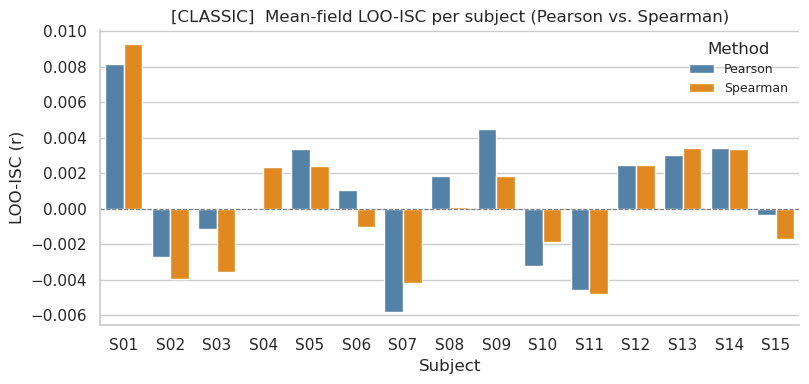

In [8]:
# ── Mean-field: average raw signal across all electrodes ──────────────────
# data: (n_subjects, n_channels, n_times) → mean_field: (n_subjects, n_times)
mean_field = data.mean(axis=1)
print(f"Mean-field shape: {mean_field.shape}  (subjects × time points)")

# ── LOO-ISC on mean-field (Pearson + Spearman) ─────────────────────────────
loo_mf_pearson = np.zeros(n_subjects)
loo_mf_spearman = np.zeros(n_subjects)
for s in range(n_subjects):
    others = np.delete(mean_field, s, axis=0).mean(axis=0)
    loo_mf_pearson[s] = float(np.corrcoef(mean_field[s], others)[0, 1])
    loo_mf_spearman[s] = float(spearmanr(mean_field[s], others).statistic)

print(
    f"\nPearson  mean-field LOO-ISC — "
    f"mean: {loo_mf_pearson.mean():.4f}  std: {loo_mf_pearson.std():.4f}  "
    f"% subjects > 0: {(loo_mf_pearson > 0).mean() * 100:.1f}%"
)
print(
    f"Spearman mean-field LOO-ISC — "
    f"mean: {loo_mf_spearman.mean():.4f}  std: {loo_mf_spearman.std():.4f}  "
    f"% subjects > 0: {(loo_mf_spearman > 0).mean() * 100:.1f}%"
)

# ── Per-subject bar chart ─────────────────────────────────────────────────
df_mf = pd.DataFrame({
    "subject": [f"S{i + 1:02d}" for i in range(n_subjects)] * 2,
    "loo_isc": np.concatenate([loo_mf_pearson, loo_mf_spearman]),
    "method": ["Pearson"] * n_subjects + ["Spearman"] * n_subjects,
})

fig_mf, ax_mf = plt.subplots(figsize=(max(8, n_subjects * 0.55), 4))
sns.barplot(
    data=df_mf, x="subject", y="loo_isc", hue="method",
    palette={"Pearson": "steelblue", "Spearman": "darkorange"},
    ax=ax_mf,
)
ax_mf.axhline(0, color="gray", ls="--", lw=0.8)
ax_mf.set_xlabel("Subject")
ax_mf.set_ylabel("LOO-ISC (r)")
ax_mf.set_title(f"[{LABEL}]  Mean-field LOO-ISC per subject (Pearson vs. Spearman)")
ax_mf.legend(frameon=False, fontsize=9, title="Method")
sns.despine(fig=fig_mf)
fig_mf.tight_layout()
if SAVE_PLOTS:
    fig_mf.savefig(
        PLOTS_DIR / f"mf_loo_isc_per_subject_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()


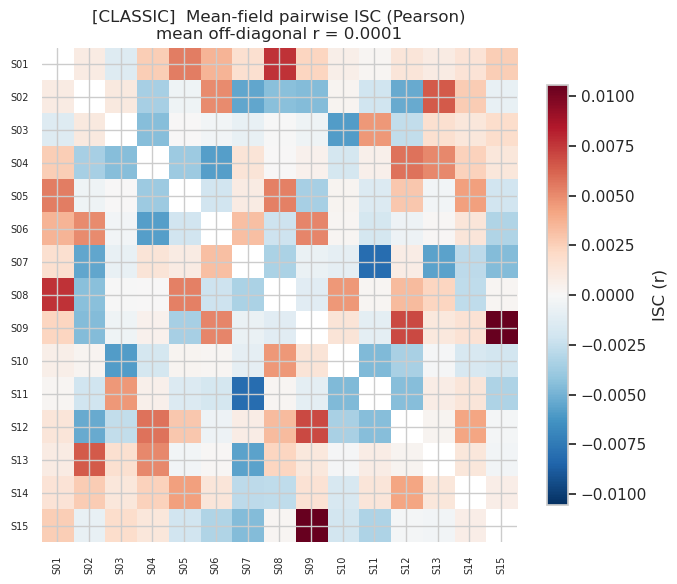

In [9]:
# ── Pairwise ISC on mean-field (Pearson) ──────────────────────────────────
pair_mf = np.eye(n_subjects)
for i in range(n_subjects):
    for j in range(i + 1, n_subjects):
        r = float(np.corrcoef(mean_field[i], mean_field[j])[0, 1])
        pair_mf[i, j] = r
        pair_mf[j, i] = r

mat_mf_display = pair_mf.copy()
np.fill_diagonal(mat_mf_display, np.nan)
vmax_mf = max(float(np.nanmax(np.abs(mat_mf_display))), 0.01)
off_diag_mf = ~np.eye(n_subjects, dtype=bool)
mean_off_mf = float(pair_mf[off_diag_mf].mean())

fig_pw, ax_pw = plt.subplots(figsize=(7, 6))
im = ax_pw.imshow(
    mat_mf_display, cmap="RdBu_r", vmin=-vmax_mf, vmax=vmax_mf, aspect="auto"
)
plt.colorbar(im, ax=ax_pw, label="ISC (r)", shrink=0.85)
_subj_lbl = [f"S{i + 1:02d}" for i in range(n_subjects)]
ax_pw.set_xticks(range(n_subjects))
ax_pw.set_yticks(range(n_subjects))
ax_pw.set_xticklabels(_subj_lbl, rotation=90, fontsize=7)
ax_pw.set_yticklabels(_subj_lbl, fontsize=7)
ax_pw.set_title(
    f"[{LABEL}]  Mean-field pairwise ISC (Pearson)\n"
    f"mean off-diagonal r = {mean_off_mf:.4f}"
)
sns.despine(fig=fig_pw, left=True, bottom=True)
fig_pw.tight_layout()
if SAVE_PLOTS:
    fig_pw.savefig(
        PLOTS_DIR / f"mf_pairwise_isc_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()


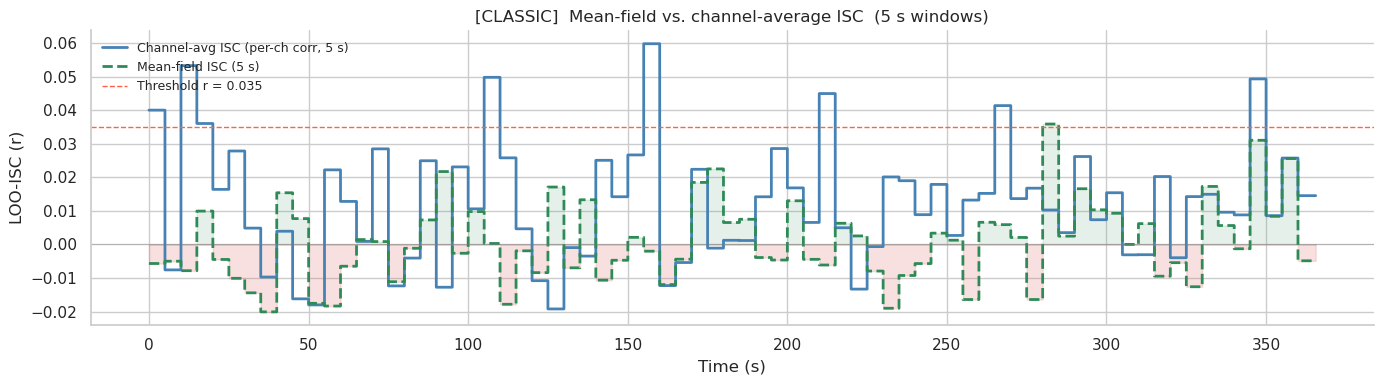


Correlation between channel-avg ISC and mean-field ISC: r = 0.0294
Mean-field LOO-ISC — mean: 0.0007  std: 0.0119  % windows > threshold: 1.4%


In [12]:
# ── Sliding-window LOO-ISC on mean-field (medium window, non-overlapping) ──
_win_mf = int(round(WINDOW_MED_SEC * sfreq))
_starts_mf = np.arange(0, n_times - _win_mf + 1, _win_mf)
plt.show()
isc_mf_tc = np.zeros(len(_starts_mf))
for _wi, _start in enumerate(_starts_mf):
    _block = mean_field[:, _start : _start + _win_mf]
    _vals = []
    for s in range(n_subjects):
        _others = np.delete(_block, s, axis=0).mean(axis=0)
        _vals.append(float(np.corrcoef(_block[s], _others)[0, 1]))
    isc_mf_tc[_wi] = float(np.mean(_vals))

plt.show()
mf_step_arr = _make_step_arr(isc_mf_tc, _win_mf, n_times)
t_mf_ds = np.arange(n_times)[::ds] / sfreq

# ── Comparison: mean-field vs. channel-average ISC time course ────────────
fig_mf2, ax_mf2 = plt.subplots(figsize=(14, 4))
ax_mf2.step(
    t_ds, med["step_arr"][::ds], where="post",
    color="steelblue", lw=2.0,
    label=f"Channel-avg ISC (per-ch corr, {WINDOW_MED_SEC:.0f} s)",
)
ax_mf2.step(
    t_mf_ds, mf_step_arr[::ds], where="post",
    color="seagreen", lw=2.0, ls="--",
    label=f"Mean-field ISC ({WINDOW_MED_SEC:.0f} s)",
)
_mf_ds = mf_step_arr[::ds]
ax_mf2.fill_between(
    t_mf_ds, 0, np.clip(_mf_ds, 0, None),
    step="post", alpha=0.12, color="seagreen", label="_nolegend_",
)
ax_mf2.fill_between(
    t_mf_ds, np.clip(_mf_ds, None, 0), 0,
    step="post", alpha=0.22, color=C_NEG, label="_nolegend_",
)
ax_mf2.axhline(ISC_THRESHOLD, color=C_THRESH, ls="--", lw=1.0,
               label=f"Threshold r = {ISC_THRESHOLD}")
ax_mf2.axhline(0, color="gray", ls="-", lw=0.6, alpha=0.4)
ax_mf2.set_xlabel("Time (s)")
ax_mf2.set_ylabel("LOO-ISC (r)")
ax_mf2.set_title(
    f"[{LABEL}]  Mean-field vs. channel-average ISC  ({WINDOW_MED_SEC:.0f} s windows)"
)
ax_mf2.legend(frameon=False, fontsize=9)
sns.despine(fig=fig_mf2)
fig_mf2.tight_layout()
if SAVE_PLOTS:
    fig_mf2.savefig(
        PLOTS_DIR / f"mf_vs_channel_avg_isc_{LABEL}.png", dpi=150, bbox_inches="tight"
    )
plt.show()

n_len_mf = min(len(med["mean_tc"]), len(isc_mf_tc))
corr_mf = float(np.corrcoef(med["mean_tc"][:n_len_mf], isc_mf_tc[:n_len_mf])[0, 1])
print(
    f"\nCorrelation between channel-avg ISC and mean-field ISC: r = {corr_mf:.4f}"
)
print(
    f"Mean-field LOO-ISC — mean: {isc_mf_tc.mean():.4f}  "
    f"std: {isc_mf_tc.std():.4f}  "
    f"% windows > threshold: {(isc_mf_tc > ISC_THRESHOLD).mean() * 100:.1f}%"
)
